# Proyek Analisis Data: E-Commerce Public Dataset (Olist Brazil)
- **Nama:** Fadli Nur Rofik
- **Email:** fadli.nurofik@gmail.com
- **ID Dicoding:** fadli_nur_rofik

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memperoleh informasi yang mendalam.

* **Spesific (Spesifik)** — pertanyaan fokus pada satu topik tertentu, tidak bermakna ganda.
* **Measurable (Terukur)** — dapat dijawab dengan angka/metrik konkret.
* **Action-Oriented (Berorientasi Aksi)** — hasilnya memberi arahan tindakan nyata bagi stakeholder.
* **Relevant (Relevan)** — sejalan dengan tujuan bisnis/masalah yang dihadapi.
* **Time-bound (Terikat Waktu)** — ada batasan waktu yang jelas.

- **Pertanyaan 1:** Kategori produk apa yang memberikan kontribusi *revenue* tertinggi dan terendah bagi platform selama periode data yang tersedia (2016–2018), sehingga tim bisnis dapat menentukan prioritas strategi promosi per kategori?
- **Pertanyaan 2:** Bagaimana rata-rata waktu pengiriman (dari pembelian hingga diterima pelanggan) di tiap provinsi (state) pelanggan selama 2017–2018, dan apakah provinsi dengan waktu pengiriman lebih lama berkorelasi dengan *review score* yang lebih rendah, sehingga tim logistik dapat memprioritaskan perbaikan di wilayah tersebut?
- **Pertanyaan 3 (Analisis Lanjutan):** Bagaimana segmentasi pelanggan berdasarkan RFM (*Recency, Frequency, Monetary*) hingga akhir periode data (Agustus 2018), dan segmen mana yang perlu diprioritaskan untuk kampanye retensi?

## Import Semua Packages/Library yang Digunakan

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Library siap digunakan.")

Library siap digunakan.


## Data Wrangling

### Gathering Data

#### Load seluruh dataset mentah (raw) E-Commerce Public Dataset

In [22]:
path = "data/"

customers_df = pd.read_csv(path + "customers_dataset.csv")
geolocation_df = pd.read_csv(path + "geolocation_dataset.csv")
order_items_df = pd.read_csv(path + "order_items_dataset.csv")
order_payments_df = pd.read_csv(path + "order_payments_dataset.csv")
order_reviews_df = pd.read_csv(path + "order_reviews_dataset.csv")
orders_df = pd.read_csv(path + "orders_dataset.csv")
product_category_df = pd.read_csv(path + "product_category_name_translation.csv")
products_df = pd.read_csv(path + "products_dataset.csv")
sellers_df = pd.read_csv(path + "sellers_dataset.csv")

for name, df in [("customers", customers_df), ("geolocation", geolocation_df),
                  ("order_items", order_items_df), ("order_payments", order_payments_df),
                  ("order_reviews", order_reviews_df), ("orders", orders_df),
                  ("product_category", product_category_df), ("products", products_df),
                  ("sellers", sellers_df)]:
    print(f"{name:20s}: {df.shape}")

customers           : (99441, 5)
geolocation         : (1000163, 5)
order_items         : (112650, 7)
order_payments      : (103886, 5)
order_reviews       : (99224, 7)
orders              : (99441, 8)
product_category    : (71, 2)
products            : (32951, 9)
sellers             : (3095, 4)


In [23]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset terdiri dari 9 tabel terpisah (customers, orders, order_items, order_payments, order_reviews, products, product_category_name_translation, sellers, geolocation) yang saling terhubung melalui `order_id`, `customer_id`, `product_id`, dan `seller_id`.
- Diperlukan proses penggabungan (merge) sebelum dapat menjawab pertanyaan bisnis.

### Assessing Data

#### Identifying missing value, invalid value, duplicate data, dan tipe data yang belum sesuai

In [24]:
print("=== orders_df info ===")
orders_df.info()
print("\nMissing value orders_df:\n", orders_df.isna().sum())
print("\nJumlah duplikat orders_df:", orders_df.duplicated().sum())

=== orders_df info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing value orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrie

In [25]:
print("=== products_df ===")
print("Missing value:\n", products_df.isna().sum())
print("\nJumlah duplikat:", products_df.duplicated().sum())

=== products_df ===
Missing value:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Jumlah duplikat: 0


In [26]:
print("=== order_reviews_df ===")
print("Missing value:\n", order_reviews_df.isna().sum())
print("\nDistribusi review_score:\n", order_reviews_df['review_score'].value_counts().sort_index())

=== order_reviews_df ===
Missing value:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Distribusi review_score:
 review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [27]:
for name, df in [("customers", customers_df), ("order_items", order_items_df),
                  ("order_payments", order_payments_df), ("sellers", sellers_df),
                  ("product_category", product_category_df)]:
    print(f"{name}: duplikat = {df.duplicated().sum()}, missing = {df.isna().sum().sum()}")

customers: duplikat = 0, missing = 0
order_items: duplikat = 0, missing = 0
order_payments: duplikat = 0, missing = 0
sellers: duplikat = 0, missing = 0
product_category: duplikat = 0, missing = 0


In [28]:
print(orders_df['order_status'].value_counts())
print("\nRentang tanggal order_purchase_timestamp:")
print(pd.to_datetime(orders_df['order_purchase_timestamp']).min(), "s/d",
      pd.to_datetime(orders_df['order_purchase_timestamp']).max())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Rentang tanggal order_purchase_timestamp:
2016-09-04 21:15:19 s/d 2018-10-17 17:30:18


**Steps to Take:**
- Kolom bertipe tanggal pada `orders_df` (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) masih bertipe `object`, perlu dikonversi ke `datetime`.
- Missing value pada `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` bersifat wajar (order belum sampai tahap tersebut, misal masih `shipped`/`canceled`) sehingga dibiarkan sebagai `NaT`, bukan dihapus.
- Missing value `product_category_name` pada `products_df` (610 baris) diisi dengan label `"unknown"` agar produk tetap bisa dianalisis tanpa mengurangi jumlah data.
- Missing value pada `order_reviews_df` (`review_comment_title`, `review_comment_message`) bersifat wajar karena komentar teks bersifat opsional bagi pelanggan, sehingga dibiarkan dan tidak memengaruhi kolom `review_score` yang akan digunakan.
- Tidak ditemukan data duplikat pada seluruh tabel.

**Insight:** (Opsional)
- Order dengan status `delivered` mendominasi (96.478 dari 99.441 order, ±97%), sehingga analisis performa penjualan difokuskan pada order berstatus `delivered` agar mencerminkan transaksi yang benar-benar selesai.
- Data mencakup periode September 2016 hingga Oktober 2018, namun volume transaksi baru stabil mulai awal 2017.

### Cleaning Data

#### Fixing tipe data tanggal dan missing value

In [29]:
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")
products_df = products_df.merge(product_category_df, on="product_category_name", how="left")
products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")

numeric_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
for col in numeric_cols:
    products_df[col] = products_df[col].fillna(products_df[col].median())

order_reviews_df = order_reviews_df.drop_duplicates(subset="review_id")

print("orders_df dtypes setelah cleaning:")
print(orders_df[date_cols].dtypes)
print("\nSisa missing value products_df:\n", products_df.isna().sum())

orders_df dtypes setelah cleaning:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Sisa missing value products_df:
 product_id                         0
product_category_name              0
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
product_category_name_english      0
dtype: int64


#### Menggabungkan seluruh tabel menjadi satu dataset analisis (main_df)

In [30]:
payments_agg = order_payments_df.groupby("order_id")["payment_value"].sum().reset_index()
reviews_unique = order_reviews_df[["order_id", "review_score"]].drop_duplicates(subset="order_id")

items_products = order_items_df.merge(
    products_df[["product_id", "product_category_name_english"]], on="product_id", how="left"
)

main_df = orders_df.merge(customers_df, on="customer_id", how="left")
main_df = main_df.merge(items_products, on="order_id", how="left")
main_df = main_df.merge(payments_agg, on="order_id", how="left")
main_df = main_df.merge(reviews_unique, on="order_id", how="left")

main_df["delivery_time_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_purchase_timestamp"]
).dt.days

print("Ukuran main_df:", main_df.shape)
main_df.head()

Ukuran main_df: (113425, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,payment_value,review_score,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,38.71,4.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery,141.46,4.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto,179.12,5.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,72.20,5.0,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,stationery,28.62,5.0,2.0


**Insight:** (Opsional)
- `main_df` menggabungkan informasi order, pelanggan, item pesanan, kategori produk, total pembayaran, dan skor ulasan ke dalam satu tabel level *order-item*, sehingga siap digunakan untuk EDA maupun sebagai sumber data dashboard.
- Kolom `delivery_time_days` dihitung sebagai selisih hari antara `order_purchase_timestamp` dan `order_delivered_customer_date`, dan akan bernilai kosong (`NaN`) untuk order yang belum diterima pelanggan.

## Exploratory Data Analysis (EDA)

### Explore status order, tren bulanan, kategori produk, dan waktu pengiriman

In [31]:
delivered_df = main_df[main_df["order_status"] == "delivered"].copy()
print("Jumlah baris order-item berstatus delivered:", len(delivered_df))
print("\nDistribusi status order:\n", main_df["order_status"].value_counts())

Jumlah baris order-item berstatus delivered: 110197

Distribusi status order:
 order_status
delivered      110197
shipped          1186
canceled          706
unavailable       610
invoiced          361
processing        357
created             5
approved            3
Name: count, dtype: int64


In [32]:
monthly_orders = (
    delivered_df.assign(period=delivered_df["order_purchase_timestamp"].dt.to_period("M"))
    .groupby("period")["order_id"].nunique()
)
print(monthly_orders)

period
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: order_id, dtype: int64


In [33]:
category_revenue = (
    delivered_df.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)
print("5 kategori revenue tertinggi:\n", category_revenue.head())
print("\n5 kategori revenue terendah:\n", category_revenue.tail())

5 kategori revenue tertinggi:
 product_category_name_english
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
Name: price, dtype: float64

5 kategori revenue terendah:
 product_category_name_english
flowers                      1110.04
home_comfort_2                760.27
cds_dvds_musicals             730.00
fashion_childrens_clothes     519.95
security_and_services         283.29
Name: price, dtype: float64


In [34]:
state_summary = (
    delivered_df.groupby("customer_state")
    .agg(avg_delivery_days=("delivery_time_days", "mean"),
         avg_review_score=("review_score", "mean"),
         jumlah_order=("order_id", "nunique"))
    .sort_values("avg_delivery_days", ascending=False)
)
print(state_summary.round(2))
print("\nKorelasi rata-rata waktu pengiriman vs rata-rata review score antar provinsi:",
      round(state_summary["avg_delivery_days"].corr(state_summary["avg_review_score"]), 3))

                avg_delivery_days  avg_review_score  jumlah_order
customer_state                                                   
RR                          27.83              3.89            41
AP                          27.75              4.26            67
AM                          25.96              4.11           145
AL                          23.99              3.84           397
PA                          23.30              3.84           946
MA                          21.20              3.75           717
SE                          20.98              3.89           335
CE                          20.54              3.88          1279
AC                          20.33              4.16            80
PB                          20.12              4.03           517
RO                          19.28              4.08           243
PI                          18.93              3.96           476
RN                          18.87              4.11           474
BA        

**Insight:** (Opsional)
- Jumlah order bulanan naik cukup stabil dari puluhan pada akhir 2016 menjadi ribuan per bulan sejak pertengahan 2017, menunjukkan platform tumbuh pesat sepanjang periode data.
- Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` menjadi penyumbang revenue terbesar, sementara kategori seperti `security_and_services`, `fashion_childrens_clothes`, dan `cds_dvds_musicals` memberi kontribusi sangat kecil.
- Terdapat korelasi negatif (sekitar -0,31) antara rata-rata waktu pengiriman dan rata-rata review score di level provinsi — provinsi dengan pengiriman lebih lama (mis. RR, AP, AM) cenderung memiliki review score rata-rata yang berbeda dibanding provinsi dengan pengiriman cepat (mis. SP).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memberikan kontribusi revenue tertinggi dan terendah?

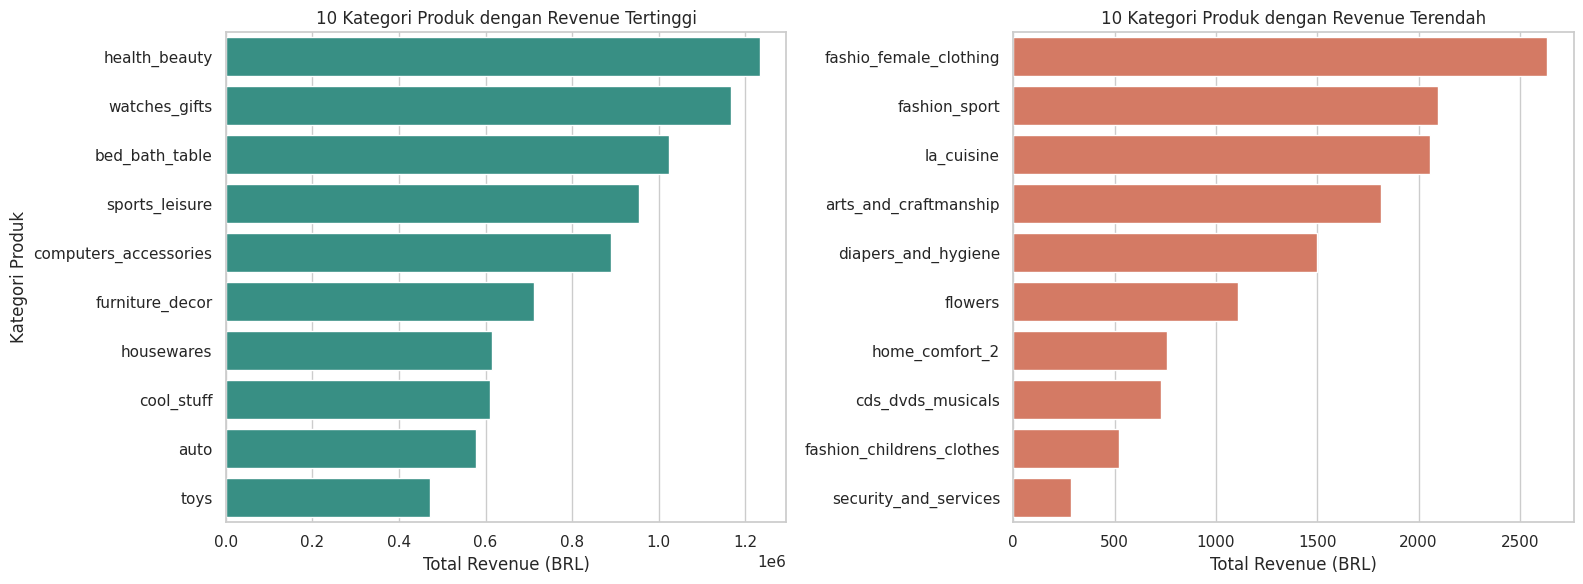

In [35]:
top10 = category_revenue.head(10)
bottom10 = category_revenue.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top10.values, y=top10.index, ax=axes[0], color="#2a9d8f")
axes[0].set_title("10 Kategori Produk dengan Revenue Tertinggi")
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].set_ylabel("Kategori Produk")

sns.barplot(x=bottom10.values, y=bottom10.index, ax=axes[1], color="#e76f51")
axes[1].set_title("10 Kategori Produk dengan Revenue Terendah")
axes[1].set_xlabel("Total Revenue (BRL)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana waktu pengiriman per provinsi dan hubungannya dengan review score?

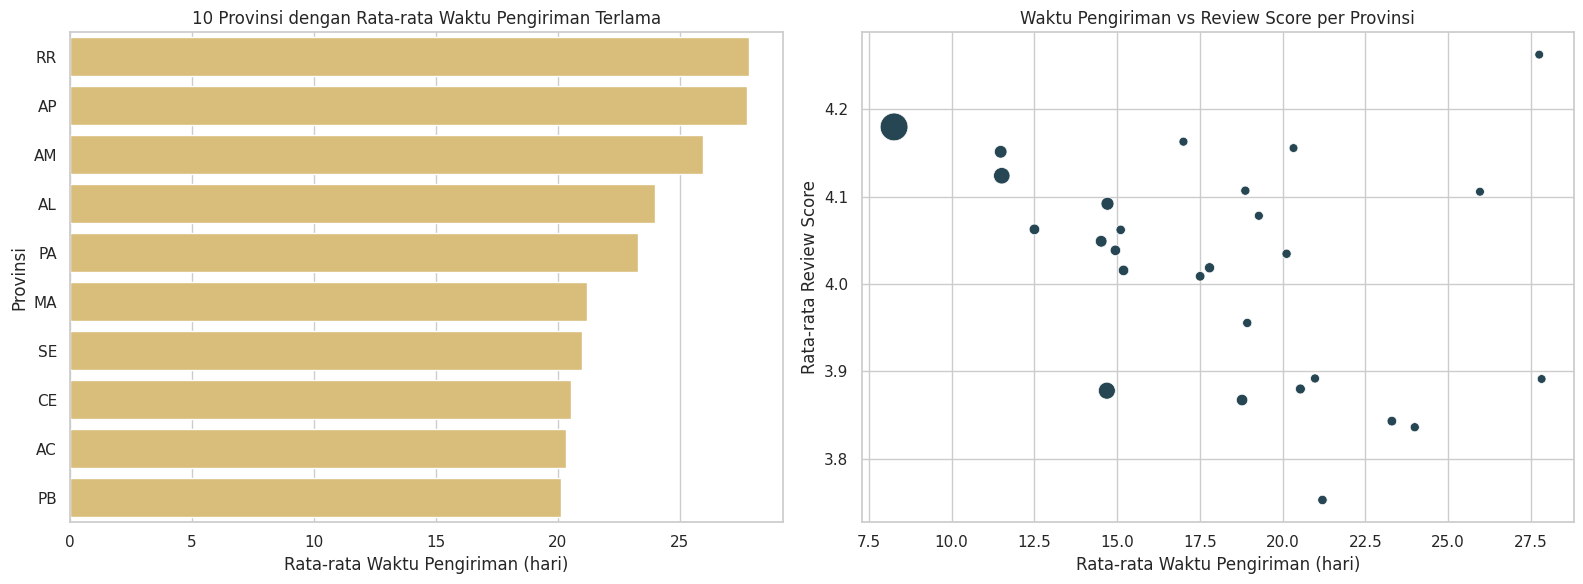

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_state = state_summary.head(10)
sns.barplot(x=top_state["avg_delivery_days"], y=top_state.index, ax=axes[0], color="#e9c46a")
axes[0].set_title("10 Provinsi dengan Rata-rata Waktu Pengiriman Terlama")
axes[0].set_xlabel("Rata-rata Waktu Pengiriman (hari)")
axes[0].set_ylabel("Provinsi")

sns.scatterplot(data=state_summary, x="avg_delivery_days", y="avg_review_score",
                 size="jumlah_order", sizes=(40, 400), legend=False, ax=axes[1], color="#264653")
axes[1].set_title("Waktu Pengiriman vs Review Score per Provinsi")
axes[1].set_xlabel("Rata-rata Waktu Pengiriman (hari)")
axes[1].set_ylabel("Rata-rata Review Score")

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Pertanyaan 1** terjawab: kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` adalah tiga besar penyumbang revenue, sedangkan `security_and_services`, `fashion_childrens_clothes`, dan `cds_dvds_musicals` adalah kontributor terkecil — kategori-kategori kecil ini kandidat untuk promosi/bundling agar penjualannya meningkat.
- **Pertanyaan 2** terjawab: provinsi-provinsi di luar wilayah tenggara (mis. RR, AP, AM, AL, PA) memiliki rata-rata waktu pengiriman >20 hari, jauh lebih lama dibanding SP (±8 hari). Scatter plot menunjukkan pola umum: provinsi dengan pengiriman lebih cepat cenderung memiliki review score rata-rata yang sedikit lebih tinggi, didukung korelasi negatif sekitar -0,31.

## Analisis Lanjutan (Opsional)

**Tujuan Analisis Lanjutan — RFM Analysis (tanpa algoritma machine learning):**
Analisis ini bertujuan mengelompokkan pelanggan berdasarkan perilaku transaksi mereka menggunakan tiga dimensi:
- **Recency**: jumlah hari sejak transaksi terakhir pelanggan (dihitung dari tanggal snapshot, yaitu satu hari setelah transaksi terakhir pada dataset).
- **Frequency**: jumlah order unik yang pernah dilakukan pelanggan.
- **Monetary**: total nilai pembayaran yang pernah dikeluarkan pelanggan.

Segmentasi dilakukan dengan *manual binning* (`pd.qcut`, kuartil) pada tiap dimensi lalu digabung dengan aturan bisnis sederhana — bukan menggunakan algoritma machine learning seperti K-Means.

In [37]:
delivered_orders = orders_df[orders_df["order_status"] == "delivered"]
cust_orders = delivered_orders.merge(customers_df, on="customer_id", how="left")
cust_orders = cust_orders.merge(payments_agg, on="order_id", how="left")

snapshot_date = cust_orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = cust_orders.groupby("customer_unique_id").agg(
    last_purchase=("order_purchase_timestamp", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum")
).reset_index()
rfm_df["recency"] = (snapshot_date - rfm_df["last_purchase"]).dt.days

rfm_df["R"] = pd.qcut(rfm_df["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df["F"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df["M"] = pd.qcut(rfm_df["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

def assign_segment(row):
    if row["R"] >= 3 and row["F"] >= 3 and row["M"] >= 3:
        return "Champions"
    elif row["R"] >= 3 and row["F"] < 3:
        return "Potential Loyalist"
    elif row["R"] < 3 and row["F"] >= 3:
        return "At Risk"
    elif row["R"] <= 2 and row["F"] <= 2 and row["M"] <= 2:
        return "Hibernating/Lost"
    else:
        return "Need Attention"

rfm_df["segment"] = rfm_df.apply(assign_segment, axis=1)

segment_summary = rfm_df.groupby("segment").agg(
    jumlah_pelanggan=("customer_unique_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean")
).sort_values("jumlah_pelanggan", ascending=False)

print(segment_summary.round(2))

                    jumlah_pelanggan  avg_recency  avg_frequency  avg_monetary
segment                                                                       
Potential Loyalist             23356       112.05           1.00        160.98
At Risk                        23188       364.11           1.06        166.44
Need Attention                 22412       238.06           1.01        164.65
Champions                      12291       112.62           1.13        271.83
Hibernating/Lost               12111       366.13           1.00         63.75


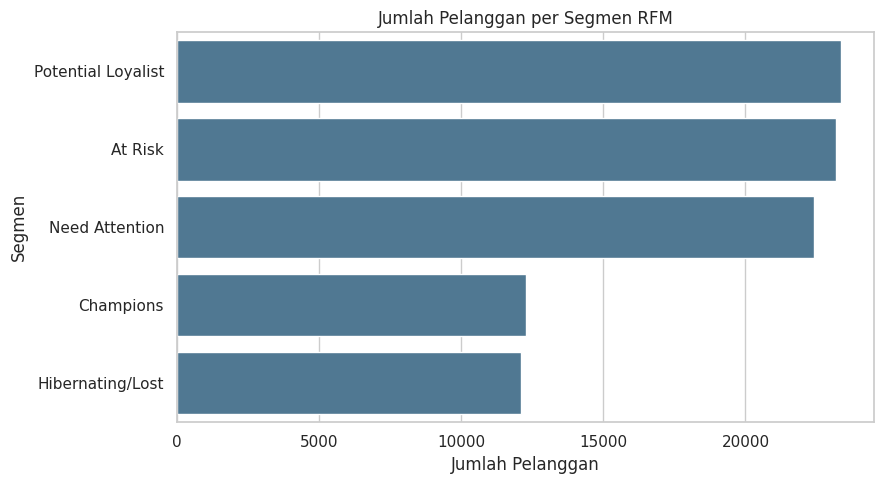

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
order_seg = segment_summary.index
sns.barplot(x=segment_summary["jumlah_pelanggan"], y=order_seg, color="#457b9d", ax=ax)
ax.set_title("Jumlah Pelanggan per Segmen RFM")
ax.set_xlabel("Jumlah Pelanggan")
ax.set_ylabel("Segmen")
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Segmen `Potential Loyalist` dan `At Risk` merupakan dua segmen terbesar, masing-masing sekitar seperempat dari total pelanggan.
- Segmen `Champions` (pelanggan dengan recency, frequency, dan monetary yang baik) memiliki rata-rata belanja (`monetary`) tertinggi dibanding segmen lain, menjadikannya target utama program loyalitas.
- Segmen `Hibernating/Lost` memiliki recency rata-rata paling tinggi (paling lama tidak bertransaksi) dan monetary rata-rata paling rendah, sehingga menjadi kandidat kampanye reaktivasi bila potensi nilainya masih dianggap layak.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` adalah tiga kategori dengan kontribusi revenue tertinggi, sedangkan `security_and_services`, `fashion_childrens_clothes`, dan `cds_dvds_musicals` memberikan kontribusi revenue paling rendah selama periode data yang tersedia.
- **Conclusion pertanyaan 2:** Rata-rata waktu pengiriman bervariasi cukup besar antar provinsi (±8 hari di SP hingga ±28 hari di RR), dan secara umum provinsi dengan waktu pengiriman lebih lama cenderung memiliki review score rata-rata yang lebih rendah (korelasi ≈ -0,31).
- **Conclusion pertanyaan 3 (RFM):** Pelanggan dapat dikelompokkan ke dalam lima segmen (Champions, Potential Loyalist, At Risk, Need Attention, Hibernating/Lost) berdasarkan pola transaksi mereka, dengan segmen `At Risk` dan `Hibernating/Lost` bersama-sama mencakup sebagian besar pelanggan yang berisiko tidak kembali bertransaksi.

**Rekomendasi Action Item:**
- Prioritaskan alokasi anggaran promosi/iklan pada kategori dengan revenue rendah namun berpotensi (mis. `fashion_childrens_clothes`) untuk menguji apakah rendahnya penjualan disebabkan oleh kurangnya eksposur, sekaligus mempertahankan strategi pada kategori dengan revenue tertinggi.
- Evaluasi dan tingkatkan kapasitas logistik/mitra ekspedisi di provinsi dengan waktu pengiriman terlama (mis. RR, AP, AM, AL, PA) karena berkorelasi dengan review score yang lebih rendah, misalnya dengan menambah gudang regional atau mitra kurir lokal.
- Jalankan kampanye retensi (mis. diskon khusus atau program loyalitas) yang ditargetkan pada segmen `At Risk` dan `Hibernating/Lost` hasil analisis RFM, karena kedua segmen ini berjumlah besar namun berisiko churn.